# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en el Classroom como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).
2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.
3. Normaliza
4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada
5. Reserva un 20% de los datos del entrenamiento para validar.
6. Representa el objeto history
7. Evalua el modelo con los datos de test
8. Representa algunos de los paisajes donde el modelo comete errores
9. Crea una matriz de confusión con los errores del modelo

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import cv2
from skimage.io import imread

from tensorflow import keras
from sklearn.metrics import confusion_matrix

2026-01-07 20:47:09.417098: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-07 20:47:09.454400: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-07 20:47:10.303772: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/david/The_Bridge/2025-10-DS-FT-BIL/2025-OCT-BILBAO-FT-Data-Science/.venv/l

In [2]:
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}
class_names_label

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [3]:
ROOTPATH = '/home/david/The_Bridge/01-Datasets/Paisajes'

In [4]:
os.listdir(ROOTPATH)

['seg_test', 'seg_train']

In [5]:
IMAGE_SIZE = (32,32)
TRAIN_PATH = ROOTPATH + "/seg_train"
TEST_PATH = ROOTPATH + "/seg_test"

In [6]:
def read_data(path, im_size):
    X = []
    y = []

    for folder in os.listdir(path):
        label = class_names_label[folder]
        folder_path = os.path.join(path, folder)

        for file in os.listdir(folder_path):
            image_path = os.path.join(folder_path, file)
            try:
                image = imread(image_path)
                smallimage = cv2.resize(image, im_size)
                X.append(smallimage)
                y.append(label)
            except:
                print("Error en lectura imagen", image_path)

    return np.array(X), np.array(y)


In [7]:
X_train, y_train = read_data(TRAIN_PATH, IMAGE_SIZE)
X_test, y_test = read_data(TEST_PATH, IMAGE_SIZE)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14034, 32, 32, 3)
(3000, 32, 32, 3)
(14034,)
(3000,)


In [8]:
pd.Series(y_train).value_counts()

3    2512
2    2404
5    2382
4    2274
1    2271
0    2191
Name: count, dtype: int64

In [9]:
pd.Series(y_test).value_counts()

2    553
3    525
4    510
5    501
1    474
0    437
Name: count, dtype: int64

In [10]:
y_train[:100]

array([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5])

In [11]:
from sklearn.utils import shuffle

X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

In [12]:
y_train[:100]

array([5, 4, 4, 1, 0, 2, 0, 2, 5, 4, 5, 0, 4, 1, 2, 1, 1, 4, 3, 0, 2, 5,
       2, 2, 4, 3, 0, 4, 5, 0, 4, 4, 4, 2, 3, 2, 4, 1, 5, 3, 4, 3, 5, 1,
       5, 4, 3, 3, 0, 4, 1, 5, 2, 0, 4, 1, 5, 1, 3, 0, 0, 2, 1, 0, 2, 0,
       2, 3, 4, 0, 1, 3, 4, 3, 2, 3, 2, 3, 4, 0, 1, 4, 0, 3, 2, 0, 3, 1,
       1, 5, 0, 0, 1, 3, 4, 3, 4, 1, 3, 3])

mountain


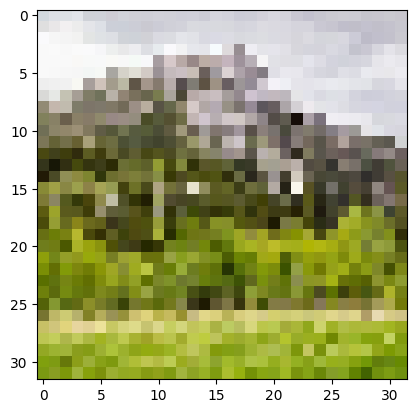

In [13]:
index = np.random.randint(X_train.shape[0])
print(class_names[y_train[index]])
plt.imshow(X_train[index]);

In [14]:
X_train

array([[[[239, 254, 254],
         [244, 253, 252],
         [252, 254, 253],
         ...,
         [ 74,  75,  73],
         [ 13,  13,  13],
         [162, 164, 158]],

        [[240, 254, 255],
         [245, 254, 253],
         [254, 255, 254],
         ...,
         [165, 167, 164],
         [ 25,  27,  25],
         [143, 144, 139]],

        [[239, 250, 253],
         [242, 254, 254],
         [247, 253, 254],
         ...,
         [103, 105, 102],
         [ 54,  58,  59],
         [ 13,  13,  11]],

        ...,

        [[176, 193, 208],
         [174, 191, 207],
         [186, 203, 222],
         ...,
         [170, 171, 156],
         [ 63,  60,  50],
         [158, 160, 148]],

        [[158, 172, 182],
         [180, 187, 197],
         [169, 180, 190],
         ...,
         [174, 176, 162],
         [ 91,  91,  86],
         [131, 130, 122]],

        [[161, 171, 181],
         [144, 152, 165],
         [169, 177, 188],
         ...,
         [166, 171, 162],
        

In [15]:
X_train[0][0][0][0]

np.uint8(239)

In [16]:
print(X_train.min())
print(X_train.max())

0
255


In [17]:
X_train = X_train/255
X_test = X_test/255

In [18]:
print(X_train.min())
print(X_train.max())

0.0
1.0


In [19]:
X_train.shape

(14034, 32, 32, 3)

In [20]:
model = keras.Sequential([
    keras.layers.Conv2D(64, (3,3), input_shape=(32,32,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(32, (3,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(16,activation="relu"),
    keras.layers.Dense(6, activation="softmax")
])

/home/david/The_Bridge/2025-10-DS-FT-BIL/2025-OCT-BILBAO-FT-Data-Science/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1767815237.876146  111856 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2532 MB memory:  -> device: 0, name: NVIDIA RTX A3000 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,190 (371.84 KB)

 Trainable params: 95,190 (371.84 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])

In [23]:
history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20


2026-01-07 20:47:25.860051: I external/local_xla/xla/service/service.cc:163] XLA service 0x7816e0005420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-07 20:47:25.860065: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A3000 Laptop GPU, Compute Capability 8.6
2026-01-07 20:47:25.880080: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-07 20:47:26.005401: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-01-07 20:47:26.030791: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-07 20:47:26.703920:

34/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3340 - loss: 1.6433

I0000 00:00:1767815248.403597  112308 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


79/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3966 - loss: 1.5152

2026-01-07 20:47:28.941289: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-07 20:47:29.528737: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_454', 16 bytes spill stores, 16 bytes spill loads

2026-01-07 20:47:29.565071: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_454', 528 bytes spill stores, 528 bytes spill loads

2026-01-07 20:47:29.650290: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_454', 24 byt

88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.4798 - loss: 1.3291 - val_accuracy: 0.5835 - val_loss: 1.1041
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6068 - loss: 1.0381 - val_accuracy: 0.6380 - val_loss: 0.9927
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6568 - loss: 0.9276 - val_accuracy: 0.6548 - val_loss: 0.9416
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6859 - loss: 0.8414 - val_accuracy: 0.6719 - val_loss: 0.8759
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7120 - loss: 0.7813 - val_accuracy: 0.6954 - val_loss: 0.8277
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7245 - loss: 0.7315 - val_accuracy: 0.7257 - val_loss: 0.7678
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7552 - loss: 0.6685 - val_accuracy: 0.7317 - val_loss: 0.7464
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7569 - loss: 0.6601 - val_accuracy: 0.7214 - val_loss: 0.7787
Ep

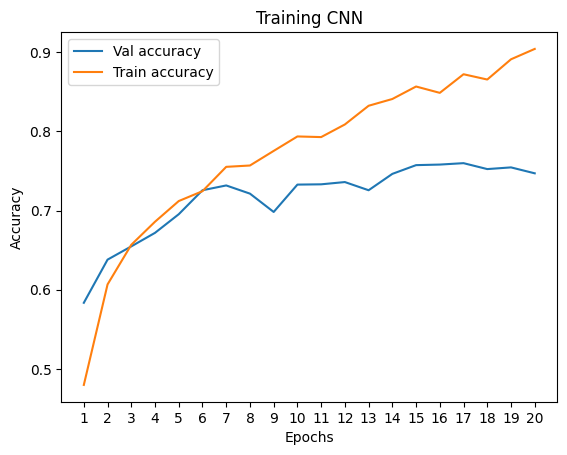

In [24]:
df_hist = pd.DataFrame(history.history, index=np.arange(1,21))
plt.plot(df_hist['val_accuracy'], label="Val accuracy")
plt.plot(df_hist['accuracy'], label="Train accuracy")
plt.title("Training CNN")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(range(1,21))
plt.legend()

In [25]:
results = model.evaluate(X_test, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7457 - loss: 0.8212


In [26]:
y_pred = model.predict(X_test)
y_pred.round(2)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([[0.01, 0.  , 0.  , 0.  , 0.  , 0.99],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  ],
       [0.93, 0.  , 0.  , 0.  , 0.  , 0.07],
       ...,
       [0.  , 0.  , 0.48, 0.31, 0.21, 0.  ],
       [0.  , 0.  , 0.48, 0.52, 0.  , 0.  ],
       [0.  , 0.  , 0.04, 0.96, 0.  , 0.  ]],
      shape=(3000, 6), dtype=float32)

In [27]:
IMAGE_SIZE = (64,64)

In [28]:
X_train, y_train = read_data(TRAIN_PATH, IMAGE_SIZE)
X_test, y_test = read_data(TEST_PATH, IMAGE_SIZE)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14034, 64, 64, 3)
(3000, 64, 64, 3)
(14034,)
(3000,)


In [29]:
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)
X_train = X_train/255
X_test = X_test/255

In [30]:
print(X_train.shape)

(14034, 64, 64, 3)


In [31]:
model_2 = keras.Sequential([
    keras.layers.Conv2D(64, (3,3), input_shape=(64,64,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(128, (3,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64, (3,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(32,activation="relu"),
    keras.layers.Dense(6, activation="softmax")
])
model_2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])
history_2 = model_2.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=30,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(patience=5)]
)

/home/david/The_Bridge/2025-10-DS-FT-BIL/2025-OCT-BILBAO-FT-Data-Science/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.5703 - loss: 1.1094 - val_accuracy: 0.5957 - val_loss: 0.9981
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6855 - loss: 0.8328 - val_accuracy: 0.7072 - val_loss: 0.7949
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7359 - loss: 0.7269 - val_accuracy: 0.7439 - val_loss: 0.7042
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7682 - loss: 0.6288 - val_accuracy: 0.7271 - val_loss: 0.7601
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7966 - loss: 0.5624 - val_accuracy: 0.7681 - val_loss: 0.6574
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8274 - loss: 0.4814 - val_accuracy: 0.7681 - val_loss: 0.6812
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8537 - loss: 0.4091 - val_accuracy: 0.7691 - val_loss: 0.6797
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8782 - loss: 0.3404 - val_acc

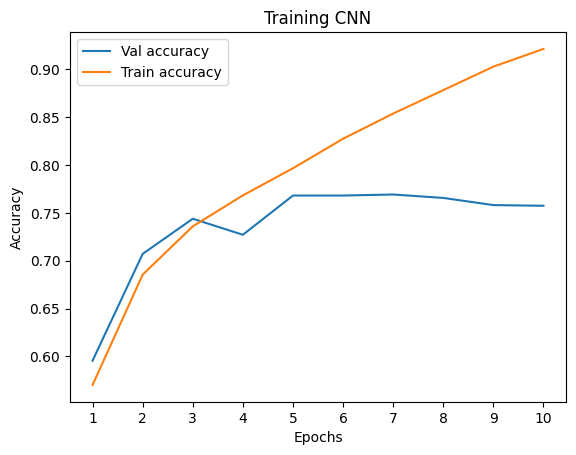

In [32]:
df_hist = pd.DataFrame(history_2.history, index=np.arange(1,11))
plt.plot(df_hist['val_accuracy'], label="Val accuracy")
plt.plot(df_hist['accuracy'], label="Train accuracy")
plt.title("Training CNN")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(range(1,11))
plt.legend()

In [33]:
results = model_2.evaluate(X_test, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7570 - loss: 0.9047


In [ ]:
y_pred = model_2.predict(X_test)
y_pred.round(2)

buildings


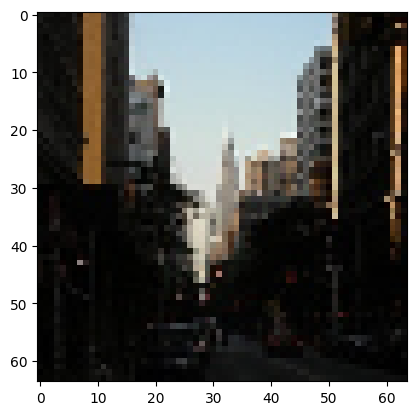

In [34]:
print(class_names[y_test[0]])
plt.imshow(X_test[0])

In [35]:
pred_labels = np.argmax(y_pred, axis=1)
print(pred_labels)
pred_names = [class_names[pred] for pred in pred_labels]
print(pred_names)

[5 2 0 ... 2 3 3]
['street', 'glacier', 'buildings', 'street', 'street', 'glacier', 'glacier', 'forest', 'street', 'buildings', 'forest', 'street', 'mountain', 'buildings', 'sea', 'mountain', 'glacier', 'buildings', 'sea', 'mountain', 'street', 'street', 'mountain', 'forest', 'sea', 'mountain', 'sea', 'glacier', 'buildings', 'glacier', 'mountain', 'street', 'mountain', 'sea', 'street', 'mountain', 'forest', 'street', 'street', 'glacier', 'street', 'street', 'street', 'mountain', 'buildings', 'sea', 'forest', 'street', 'sea', 'buildings', 'glacier', 'forest', 'buildings', 'forest', 'street', 'glacier', 'glacier', 'sea', 'sea', 'mountain', 'mountain', 'glacier', 'mountain', 'street', 'street', 'glacier', 'glacier', 'glacier', 'mountain', 'mountain', 'buildings', 'sea', 'sea', 'buildings', 'street', 'mountain', 'forest', 'sea', 'forest', 'forest', 'street', 'forest', 'mountain', 'buildings', 'buildings', 'street', 'sea', 'glacier', 'forest', 'sea', 'street', 'mountain', 'street', 'glacier

<Axes: >

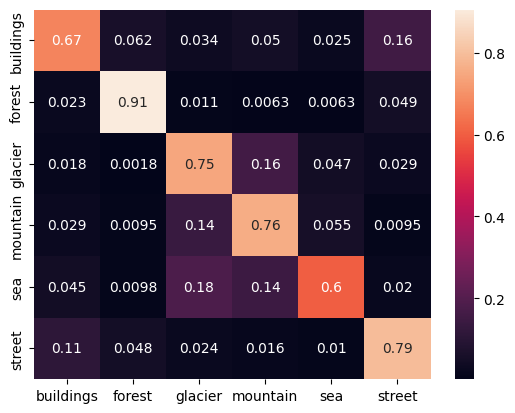

In [36]:
c_mat = confusion_matrix(y_test, pred_labels, normalize='true')
sns.heatmap(c_mat, annot=True, xticklabels=class_names, yticklabels=class_names)

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_labels))

              precision    recall  f1-score   support

           0       0.72      0.67      0.70       437
           1       0.87      0.91      0.89       474
           2       0.68      0.75      0.71       553
           3       0.67      0.76      0.71       525
           4       0.81      0.60      0.69       510
           5       0.76      0.79      0.78       501

    accuracy                           0.75      3000
   macro avg       0.75      0.75      0.75      3000
weighted avg       0.75      0.75      0.74      3000



In [38]:
model_3 = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), input_shape=(64,64,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(0.25),
    keras.layers.Conv2D(16, (3,3)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(0.25),
    keras.layers.Flatten(),
    keras.layers.Dense(32,activation="relu"),
    keras.layers.Dense(16,activation="relu"),
    keras.layers.Dense(6, activation="softmax")
])
model_3.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])
history_3 = model_3.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=30,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(patience=5)]
)

/home/david/The_Bridge/2025-10-DS-FT-BIL/2025-OCT-BILBAO-FT-Data-Science/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


2026-01-07 20:49:20.358123: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-07 20:49:20.922864: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1208', 116 bytes spill stores, 116 bytes spill loads



84/88 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3699 - loss: 1.4846

2026-01-07 20:49:24.645463: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-07 20:49:25.126000: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1208', 16 bytes spill stores, 16 bytes spill loads

2026-01-07 20:49:25.186067: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1208', 12 bytes spill stores, 12 bytes spill loads

2026-01-07 20:49:25.247983: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1208', 332 b

88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.4762 - loss: 1.2992 - val_accuracy: 0.5675 - val_loss: 1.1529
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6198 - loss: 1.0140 - val_accuracy: 0.6249 - val_loss: 1.0137
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6538 - loss: 0.9220 - val_accuracy: 0.6491 - val_loss: 0.9295
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6865 - loss: 0.8421 - val_accuracy: 0.6975 - val_loss: 0.8448
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7201 - loss: 0.7680 - val_accuracy: 0.6633 - val_loss: 0.9144
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7397 - loss: 0.7065 - val_accuracy: 0.6822 - val_loss: 0.8712
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7606 - loss: 0.6511 - val_accuracy: 0.7011 - val_loss: 0.8220
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7690 - loss: 0.6227 - val_accuracy: 0.6965 - val_loss: 0.

In [39]:
results = model_3.evaluate(X_test, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7337 - loss: 0.7905
